In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

import matplotlib.pyplot as plt
from dataset import MOViC_Dataset
from torchvision import transforms
from torchvision.transforms import (
    RandomHorizontalFlip,
    RandomVerticalFlip,
    RandomRotation,
    ColorJitter,
    ToTensor,
    Resize
)
import numpy as np

import imageio
from io import BytesIO
from IPython.display import display, Image as IPImage
from PIL import Image

True


In [3]:
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'

### Test of dataset transformations

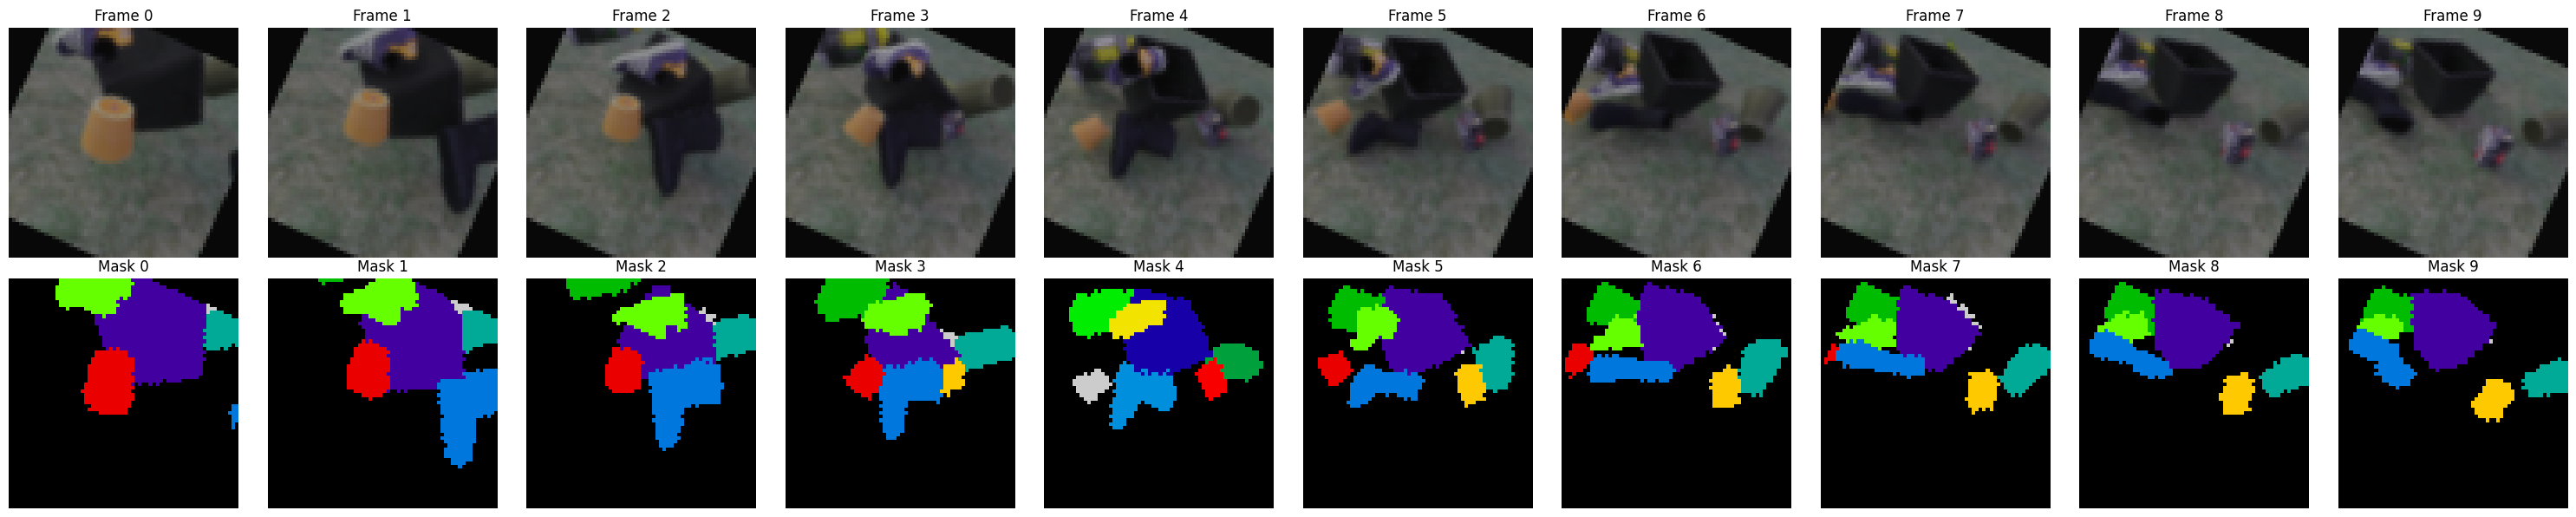

In [4]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=(-30, 30)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    )
])
dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="objects", img_size=(64, 64), transform=train_transform)
sample = dataset[2]

def show_frames_and_masks(sample, n=5, cmap="tab20"):
    """
    sample: frames, masks
    n: how many frames to show
    """
    
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    cmap = plt.get_cmap(cmap)

    for i, (frame, mask) in enumerate(zip(sample[0][:n], sample[1][:n])):
        frame = frame.permute(1, 2, 0).numpy()  # CHW -> HWC
        mask = mask.squeeze().numpy().astype(int)

        axes[0, i].imshow(frame)
        axes[0, i].set_title(f"Frame {i}")
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap=cmap, interpolation="nearest")
        axes[1, i].set_title(f"Mask {i}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

show_frames_and_masks(sample, n=10, cmap="nipy_spectral")

In [5]:
def visualize_frames_as_gif(frames, fps: int = 5, scale: float = 1.0, width: int | None = None, height: int | None = None):
    images = []
    if isinstance(frames, torch.Tensor):
        if frames.ndim == 4 and frames.shape[1] in (1,3):
            frames = frames.permute(0,2,3,1).cpu().numpy()
        for f in frames:
            arr = (f * 255).clip(0,255).astype("uint8")
            img = Image.fromarray(arr)
            # масштаб
            w, h = img.size
            if width and height:
                img = img.resize((width, height), Image.NEAREST)
            elif scale != 1.0:
                img = img.resize((int(w*scale), int(h*scale)), Image.NEAREST)
            images.append(img)

    with BytesIO() as buffer:
        imageio.mimsave(buffer, images, format="GIF", duration=1/fps)
        buffer.seek(0)
        display(IPImage(data=buffer.getvalue()))

In [6]:
# dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="rgb", img_size=(64, 64), transform=train_transform)
# new_sample = dataset[5] # list [frame1, frame2, ...]

# def show_frames_and_masks(sample, n=5, cmap="tab20"):
#     """
#     sample: [(frame, mask), ...]
#     n: сколько кадров показать
#     """
#     fig, axes = plt.subplots(1, n, figsize=(3*n, 6))
#     cmap = plt.get_cmap(cmap)

#     for i, frame in enumerate(sample[:n]):
#         frame = frame.permute(1, 2, 0).numpy()  # CHW -> HWC
#         # верхняя строка: кадры
#         axes[i].imshow(frame)
#         axes[i].set_title(f"Frame {i}")
#         axes[i].axis("off")
    

#     plt.tight_layout()
#     plt.show()

# show_frames_and_masks(new_sample, n=10, cmap="nipy_spectral")

In [7]:
# visualize_frames_as_gif(new_sample, fps=1, scale=4)

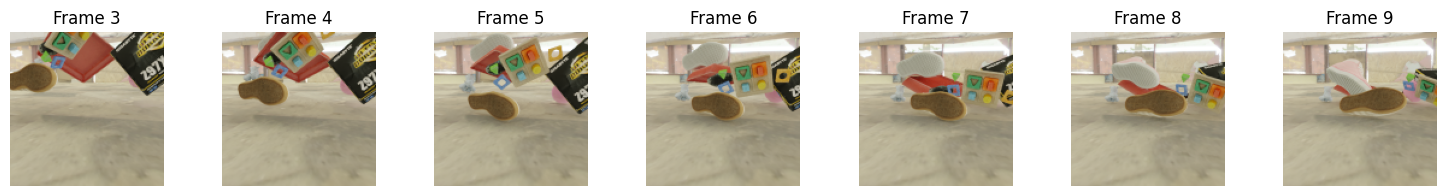

In [8]:
from utils.display_frame_sequence import display_frame_sequence

display_frame_sequence(f"{DATASET_PATH}/validation", video_id=144, num_frames=10, start_frame=3)

In [9]:
# show_frames_and_masks(new_sample.detach(), n=10, cmap="nipy_spectral")

### Transformer test (rgb based pred)

In [10]:
from save_load import load_model
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder

PATCH_SIZE = 8 #maybe bigger?
H, W = 64, 64
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=128,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=128,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

model_path = 'experiments_released/24-09-2025_10-28_Patch_AE/checkpoints'
encoder, _, _ = load_model(encoder, None, 'encoder', model_path)
decoder, _, _ = load_model(decoder, None, 'decoder', model_path)

In [11]:
from models.vpt import VideoFrameTransformer

transformer_model = VideoFrameTransformer(
    encoder=encoder,
    decoder=decoder,
    H=64, W=64,
    patch_size=PATCH_SIZE,
    embed_dim=128,
    attn_dim=16, #emb // num_of_heads!!!!!!!!!!!!!! 52
    num_heads=8,
    mlp_size=1024,
    num_tf_layers_ar=12
)

for name, param in transformer_model.named_parameters():
    print(name, param.shape, param.requires_grad)

encoder.patch_projection.0.weight torch.Size([192]) False
encoder.patch_projection.0.bias torch.Size([192]) False
encoder.patch_projection.1.weight torch.Size([128, 192]) False
encoder.patch_projection.1.bias torch.Size([128]) False
encoder.transformer_blocks.0.ln_att.weight torch.Size([128]) False
encoder.transformer_blocks.0.ln_att.bias torch.Size([128]) False
encoder.transformer_blocks.0.attn.q.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.attn.k.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.attn.v.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.attn.out_proj.weight torch.Size([128, 512]) False
encoder.transformer_blocks.0.ln_mlp.weight torch.Size([128]) False
encoder.transformer_blocks.0.ln_mlp.bias torch.Size([128]) False
encoder.transformer_blocks.0.mlp.mlp.0.weight torch.Size([512, 128]) False
encoder.transformer_blocks.0.mlp.mlp.0.bias torch.Size([512]) False
encoder.transformer_blocks.0.mlp.mlp.3.weight torch.Size([128, 51

In [12]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])


In [13]:
train_dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="rgb", img_size=(64, 64), transform=train_transform)
val_dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="validation", target="rgb", img_size=(64, 64), target_frames=15, transform=val_transform)

In [14]:
from torch.utils.data import DataLoader

B_SIZE = 16

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

frames shape: torch.Size([20, 3, 64, 64])


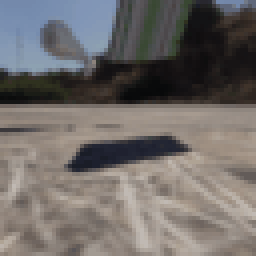

In [15]:
sample = val_dataset[0]   # обычно это (T, C, H, W) или (x, y)
if isinstance(sample, tuple):
    frames = sample[0]    # если датасет возвращает (video, target)
else:
    frames = sample       # если только видео

print("frames shape:", frames.shape)  # ожидаем (T, C, H, W)

# визуализируем как GIF
visualize_frames_as_gif(frames, fps=5, scale=4)

In [16]:
import lpips
import torch.nn as nn

class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=0.1, device="cuda"):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.lpips = lpips.LPIPS(net="alex").to(device)
        self.alpha = alpha
        self.beta = beta

    def forward(self, pred, target):
        """
        pred, target: (B, T, C, H, W)
        """
        # L1 loss по всему тензору
        loss_l1 = self.l1(pred, target)

        B, T, C, H, W = pred.shape
        loss_lpips = 0.0
        for t in range(T):
            # кадр t: (B, C, H, W)
            pred_frame = pred[:, t]
            target_frame = target[:, t]

            # LPIPS требует [-1,1]
            pred_norm = pred_frame * 2 - 1
            target_norm = target_frame * 2 - 1

            loss_lpips += self.lpips(pred_norm, target_norm).mean()

        loss_lpips = loss_lpips / T  # усреднение по времени

        return self.alpha * loss_l1 + self.beta * loss_lpips

In [17]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluate import evaluate_ar_transformer
from train_new import TrainerAutoRegressive, TrainerAR

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-4) #10-4
criterion = torch.nn.MSELoss()
#criterion = CombinedLoss(alpha=1.0, beta=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = TrainerAutoRegressive(model=transformer_model, evaluate=evaluate_ar_transformer,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler, experiment_name="TransformerPredictorRGB")
trainer.train(train_loader, val_loader, 20, eval_freq=500)

Ep 0 Iter 0: Loss=0.03534):   0%|                                                                                          | 0/20 [00:03<?, ?it/s]/home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 0, 'batch_size': 16, 'epoch': 0, 'loss': 0.03534159064292908, 'Loss': 0.18041888531297445, 'SSIM': 0.2697509088820201, 'PSNR': 14.122302334606601, 'LPIPS': 0.6610864979028702}


Ep 0 Iter 500: Loss=0.03818):   0%|                                                                                        | 0/20 [03:55<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 500, 'batch_size': 16, 'epoch': 0, 'loss': 0.03817510977387428, 'Loss': 0.16218004375696182, 'SSIM': 0.31135198252548624, 'PSNR': 14.853464107984431, 'LPIPS': 0.5909230637550354}


Ep 0 Iter 608: Loss=0.02304):   0%|                                                                                        | 0/20 [05:01<?, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 12000, 'batch_size': 16, 'epoch': 19, 'loss': 0.019876236096024513, 'Loss': 0.12076624017208815, 'SSIM': 0.37524735941062964, 'PSNR': 16.61586891614292, 'LPIPS': 0.5110438360889753}


Ep 19 Iter 12160: Loss=0.02047):   0%|                                                                                   | 0/20 [1:34:55<?, ?it/s]

Saved epoch_019_iter_12161's state to experiments/27-09-2025_21-40_TransformerPredictorRGB/checkpoints/epoch_019_iter_12161.pth


Ep 19 Iter 12179: Loss=0.02095):   0%|                                                                                   | 0/20 [1:35:05<?, ?it/s]

Training completed
Saved epoch_020_iter_12180's state to experiments/27-09-2025_21-40_TransformerPredictorRGB/checkpoints/epoch_020_iter_12180.pth


### Transformer test (object based)

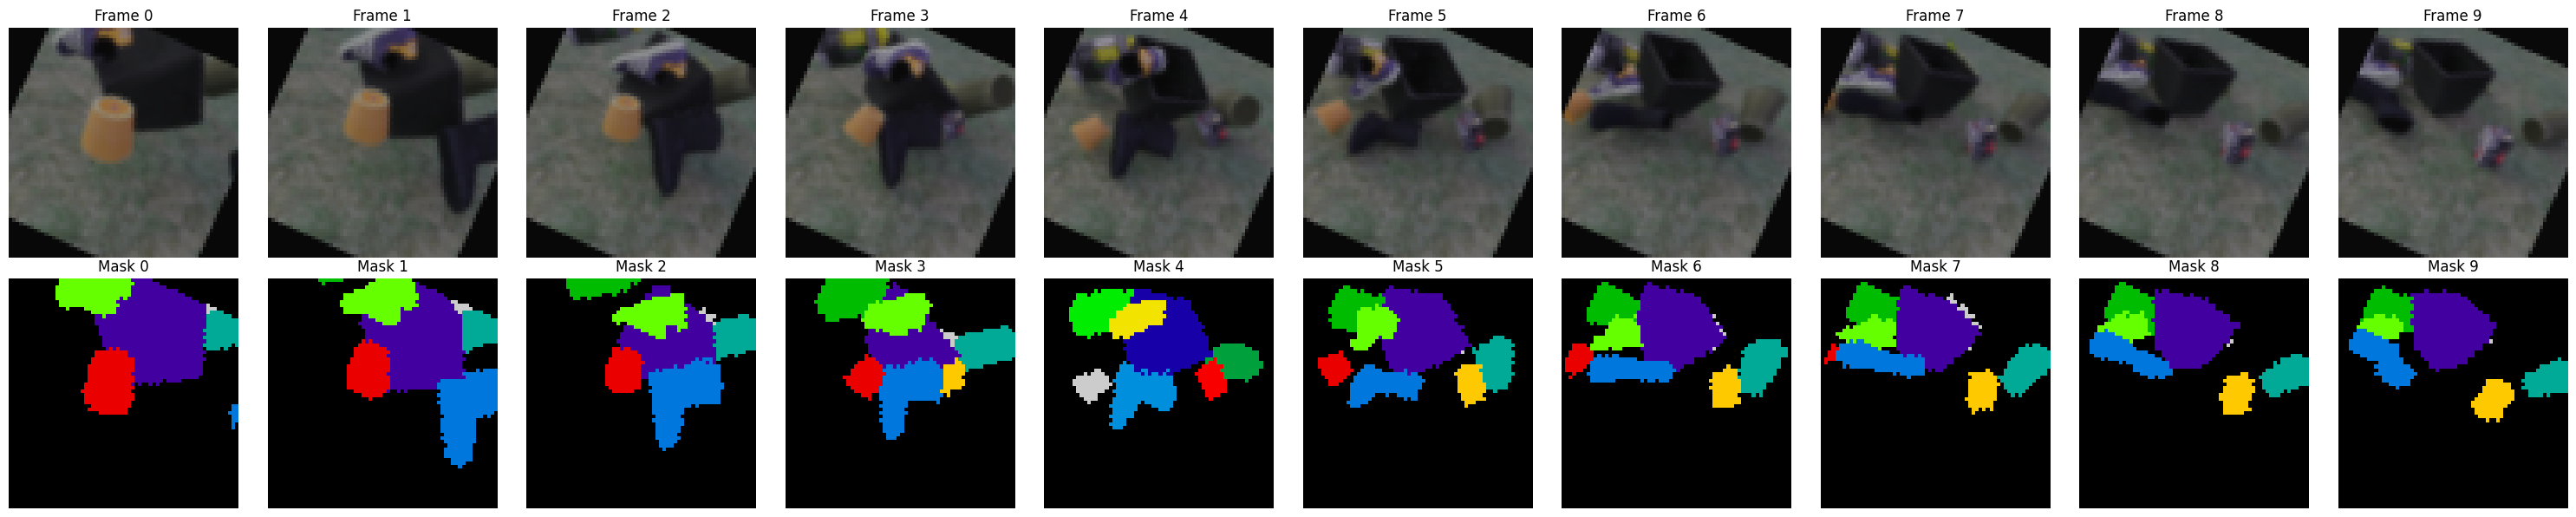

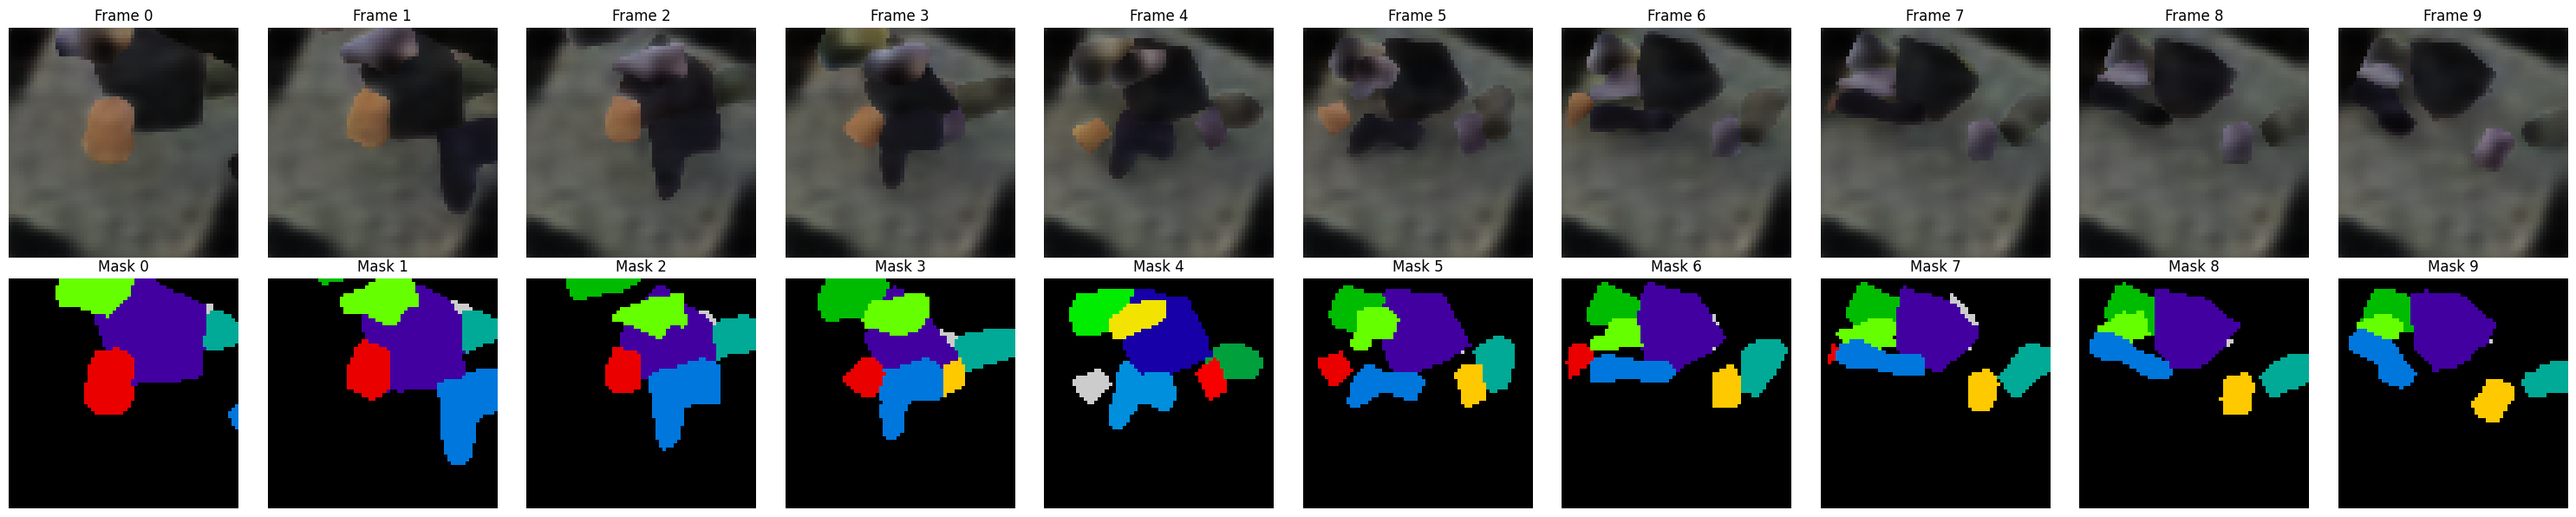

tensor([[[[ 0.0024,  0.2191, -0.3452,  ...,  0.0668, -0.0021, -0.0932],
          [-0.0340,  0.1652, -0.3119,  ..., -0.0190,  0.2022, -0.1018],
          [-0.0270,  0.2381, -0.3002,  ...,  0.1196,  0.2966, -0.0176],
          ...,
          [ 0.0543,  0.2125, -0.3573,  ..., -0.0030,  0.2641, -0.0780],
          [ 0.0108,  0.2446, -0.2998,  ...,  0.0051,  0.2647, -0.1171],
          [-0.0338,  0.1947, -0.3362,  ...,  0.0188,  0.2367, -0.0893]],

         [[ 0.0136,  0.1929, -0.3692,  ...,  0.0007,  0.2299, -0.0488],
          [-0.0006,  0.2101, -0.0994,  ...,  0.0089,  0.2521, -0.0713],
          [-0.0005,  0.1334, -0.3456,  ..., -0.0224,  0.2072, -0.0542],
          ...,
          [-0.0033,  0.1716, -0.3162,  ..., -0.0057,  0.2757, -0.0750],
          [ 0.0234,  0.2678, -0.3155,  ..., -0.0436,  0.0017, -0.0795],
          [ 0.1371,  0.2919, -0.3413,  ...,  0.0660,  0.2032, -0.0527]],

         [[ 0.0202,  0.1977, -0.3219,  ..., -0.0937,  0.2571,  0.0173],
          [-0.1125,  0.1992, -

In [10]:
from models.masked_object_transformer import MaskedObjectTransformer
from save_load import load_model

autoencoder_obj = MaskedObjectTransformer(obj_num=11, embed_dim=512,
                                          img_size=64, enc_depth=3,
                                          nhead=8, mlp_ratio=4.0)

model_path = 'experiments_released/28-09-2025_14-21_Mask_AE/checkpoints'
autoencoder_obj, _, _ = load_model(autoencoder_obj, None, 'epoch_020', model_path)
# print(sample[0].unsqueeze(0).shape)
# print( sample[1].unsqueeze(0).shape)

encoded = autoencoder_obj.encoder((sample[0].unsqueeze(0), sample[1].unsqueeze(0)))
decoded = autoencoder_obj.decoder(encoded)

show_frames_and_masks(sample, n=10, cmap="nipy_spectral")
show_frames_and_masks((decoded[0].detach().squeeze(0), decoded[1].detach().squeeze(0)), n=10, cmap="nipy_spectral")

# print(sample[1][0,:])
# print(decoded[1].detach().squeeze(0)[0,:])

input_im = torch.rand(1, 5, 3, 64, 64) 
imput_mas = torch.rand(1, 5, 64, 64)
autoencoder_obj.encoder((input_im, imput_mas))

In [11]:
from models.vpt import VideoObjectTransformer

transformer_model = VideoObjectTransformer(
    encoder=autoencoder_obj.encoder,
    decoder=autoencoder_obj.decoder,
    embed_dim=512,
    attn_dim=64, #emb // num_of_heads!!!!!!!!!!!!!! 52
    num_heads=8,
    mlp_size=1024,
    num_tf_layers_ar=12
)

for name, param in transformer_model.named_parameters():
    print(name, param.shape, param.requires_grad)

encoder.encoder_cnn.conv.0.weight torch.Size([32, 3, 4, 4]) False
encoder.encoder_cnn.conv.0.bias torch.Size([32]) False
encoder.encoder_cnn.conv.2.weight torch.Size([64, 32, 4, 4]) False
encoder.encoder_cnn.conv.2.bias torch.Size([64]) False
encoder.encoder_cnn.conv.4.weight torch.Size([128, 64, 4, 4]) False
encoder.encoder_cnn.conv.4.bias torch.Size([128]) False
encoder.encoder_cnn.conv.6.weight torch.Size([256, 128, 4, 4]) False
encoder.encoder_cnn.conv.6.bias torch.Size([256]) False
encoder.encoder_cnn.fc.weight torch.Size([512, 4096]) False
encoder.encoder_cnn.fc.bias torch.Size([512]) False
encoder.encoder.layers.0.self_attn.in_proj_weight torch.Size([1536, 512]) False
encoder.encoder.layers.0.self_attn.in_proj_bias torch.Size([1536]) False
encoder.encoder.layers.0.self_attn.out_proj.weight torch.Size([512, 512]) False
encoder.encoder.layers.0.self_attn.out_proj.bias torch.Size([512]) False
encoder.encoder.layers.0.linear1.weight torch.Size([2048, 512]) False
encoder.encoder.laye

In [12]:
from torch.utils.data import DataLoader

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

train_dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="train", target="objects", img_size=(64, 64), transform=train_transform)
val_dataset = MOViC_Dataset(root_dir=DATASET_PATH, split="validation", target="objects", img_size=(64, 64), target_frames=15, transform=val_transform)

B_SIZE = 8

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [13]:
import torch.nn.functional as F
import torch.nn as nn 


class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=0.5, device="cuda"):
        super().__init__()
        self.mse = torch.nn.MSELoss()
        self.alpha = alpha
        self.beta = beta

    def forward(self, pred, target):
        """
        pred, target: (B, T, C, H, W)
        """
        pred_frames, masks_logits = pred
        target_frames, target_masks = target
        loss_mse = self.mse(pred_frames, target_frames)

        B, T, K, H, W = masks_logits.shape

        # Ensure masks are integers on the right device
        target_masks = target_masks.long().to(masks_logits.device)
    
        # Clamp out-of-range values just in case (optional safeguard)
        #true_masks = torch.clamp(target_masks, 0, K - 1) # if num of slots < 11
    
        # Cross entropy for masks
        mask_loss = F.cross_entropy(
            masks_logits.view(B * T, K, H, W),
            target_masks.view(B * T, H, W),
        )
    
        return self.alpha * loss_mse + self.beta * mask_loss

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluate import evaluate_ar_transformer
from train_new import TrainerObjAutoRegressive

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-4) #10-4
#criterion = torch.nn.MSELoss()
criterion = CombinedLoss(alpha=1.0, beta=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = TrainerObjAutoRegressive(model=transformer_model, evaluate=evaluate_ar_transformer,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler, experiment_name="TransformerPredictorObj")
trainer.train(train_loader, val_loader, 50, eval_freq=500)

Ep 0 Iter 0: Loss=0.3027):   0%|                                                                                           | 0/50 [00:04<?, ?it/s]/home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


/home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


{'iter': 0, 'batch_size': 8, 'epoch': 0, 'loss': 0.30270299315452576, 'Loss': 0.33949462231248617, 'SSIM': 0.02503706523390086, 'PSNR': 8.094856305079908, 'LPIPS': 0.5794115129947662, 'FVD': 254.55542544078185}


Ep 0 Iter 500: Loss=0.01618):   0%|                                                                                        | 0/50 [04:12<?, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 19500, 'batch_size': 8, 'epoch': 16, 'loss': 0.011084434576332569, 'Loss': 0.08470798935741186, 'SSIM': 0.4049262771716899, 'PSNR': 19.064398369284582, 'LPIPS': 0.556996674033006, 'FVD': 80.15779932990048}


Ep 16 Iter 20000: Loss=0.0101):   0%|                                                                                    | 0/50 [2:46:36<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 20000, 'batch_size': 8, 'epoch': 16, 'loss': 0.010099295526742935, 'Loss': 0.08445514016784728, 'SSIM': 0.4077318148012246, 'PSNR': 19.137268489930573, 'LPIPS': 0.564514480249087, 'FVD': 82.24439337616707}


Ep 16 Iter 20500: Loss=0.01896):   0%|                                                                                   | 0/50 [2:50:45<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/user/imashevv1/object-repr-video-prediction/venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth
{'iter': 20500, 'batch_size': 8, 'epoch': 16, 'loss': 0.018956921994686127, 'Loss': 0.08321202616207302, 'SSIM': 0.4067001765325528, 'PSNR': 19.10368422266601, 'LPIPS': 0.5524318868398667, 'FVD': 81.24835868948723}


## Обучение автоэнкодеров

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

True


In [3]:
from dataset import ImageDataset
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
])

dataset = ImageDataset(VALIDATION_PATH, train_transform)
sample = dataset[0]

(-0.5, 63.5, 63.5, -0.5)

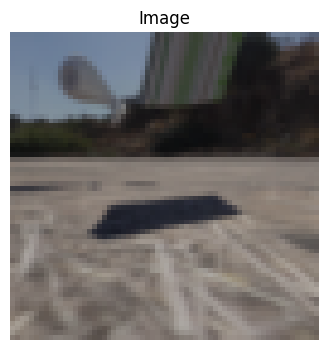

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.title("Image")
plt.axis("off")

In [5]:
train_dataset = ImageDataset(TRAIN_PATH, train_transform)
val_dataset = ImageDataset(VALIDATION_PATH, val_transform)

In [6]:
from torch.utils.data import DataLoader

B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [7]:
from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder

PATCH_SIZE = 4
H, W = 64, 64
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=512,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=2048,
                          num_tf_layers=4)

decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=512,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=512,
                          num_heads=4,
                          mlp_size=2048,
                          num_tf_layers=4)

autoencoder_img = ImageAutoencoder(encoder, decoder)

In [8]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluate import evaluate_autoencoder
from train import Trainer

optimizer = torch.optim.Adam(autoencoder_img.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler, experiment_name="TransformerPatch_AE")
trainer.train(train_loader, val_loader, 10)

Ep 0 Iter 1: Loss=10.66085):   0%|                                                                                               | 0/10 [00:14<?, ?it/s]

{'iter': 0, 'batch_size': 64, 'epoch': 0, 'loss': 1.249132513999939, 'Loss': 10.597419109750302, 'SSIM': 0.00899591801487491, 'PSNR': 8.94855463308299}


Ep 0 Iter 1000: Loss=0.02235):   0%|                                                                                             | 0/10 [02:21<?, ?it/s]

{'iter': 1000, 'batch_size': 64, 'epoch': 0, 'loss': 0.022351454943418503, 'Loss': 0.017637188615713346, 'SSIM': 0.5609307410465963, 'PSNR': 18.02917096816647}


Ep 0 Iter 2000: Loss=0.01686):   0%|                                                                                             | 0/10 [04:43<?, ?it/s]

...

{'iter': 36000, 'batch_size': 64, 'epoch': 9, 'loss': 0.005245408974587917, 'Loss': 0.004315114229610388, 'SSIM': 0.8796594416371724, 'PSNR': 24.770463551268826}


Ep 9 Iter 36511: Loss=0.00477):   0%|                                                                                          | 0/10 [1:26:38<?, ?it/s]

Saved epoch_009_iter_36511's state to experiments/19-09-2025_03-56_TransformerPatch_AE/checkpoints/epoch_009_iter_36511.pth


Ep 9 Iter 36519: Loss=0.00524):   0%|                                                                                          | 0/10 [1:26:39<?, ?it/s]

Training completed
Saved epoch_010_iter_36520's state to experiments/19-09-2025_03-56_TransformerPatch_AE/checkpoints/epoch_010_iter_36520.pth
